In [1]:
!pip install pylatexenc
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 72.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 94.3 MB/s eta 0:00:00


In [14]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display
import matplotlib.pyplot as plt
from math import pi

# 4큐비트 회로 생성 및 게이트 구성
qc = QuantumCircuit(4)

for qubit in range(4):
    qc.h(qubit)

qc.rx(pi/4, 0)

qc.ry(pi/3, 1)

qc.rz(pi/5, 2)

qc.rx(pi/6, 3)

qc.cx(0,1)

qc.cx(1,2)

qc.cx(2,3)

qc.ry(pi/8,0)

qc.rz(pi/7,1)

qc.rx(pi/9,2)

qc.ry(pi/10,3)

qc.cx(0,2)

qc.cx(1,3)


--- 양자 회로 도면 ---


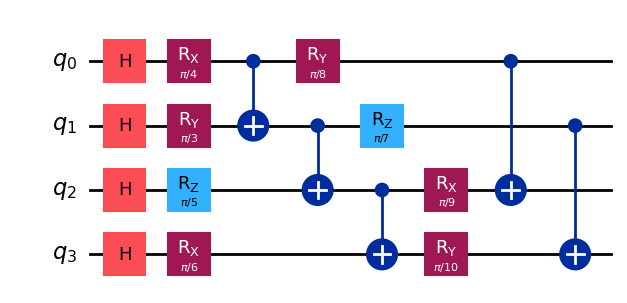

In [15]:
# 2. 회로 그림 시각화 (측정 전 상태의 회로 구조 확인)
print("--- 양자 회로 도면 ---")
fig_circuit = qc.draw("mpl")
display(fig_circuit)

In [16]:
# 3. 측정(Measurement) 추가
qc.measure_all()

In [17]:
# 4. 시뮬레이터 실행 및 컴파일
sim = AerSimulator()
compiled = transpile(qc, sim)
job = sim.run(compiled, shots=1000)
result = job.result()
counts = result.get_counts()

In [18]:
# 5. 결과 텍스트 분석 출력
print("\n--- 전체 측정 결과 딕셔너리 ---")
print(counts)

sorted_counts = sorted(
    counts.items(),
    key=lambda x: x[1],
    reverse=True
)

print("\n--- Top 5 States ---")
for state, count in sorted_counts[:5]:
    print(f"State: {state}, Count: {count}")

print(f"\nNumber of Measured States: {len(counts)}")
print(f"Most Frequent State: {sorted_counts[0]}")


--- 전체 측정 결과 딕셔너리 ---
{'1010': 57, '1000': 1, '0110': 156, '1101': 179, '1011': 28, '0011': 44, '0111': 23, '1110': 88, '1001': 131, '0101': 103, '1111': 18, '0001': 60, '0010': 110, '0000': 2}

--- Top 5 States ---
State: 1101, Count: 179
State: 0110, Count: 156
State: 1001, Count: 131
State: 0010, Count: 110
State: 0101, Count: 103

Number of Measured States: 14
Most Frequent State: ('1101', 179)



--- 결과 히스토그램 ---


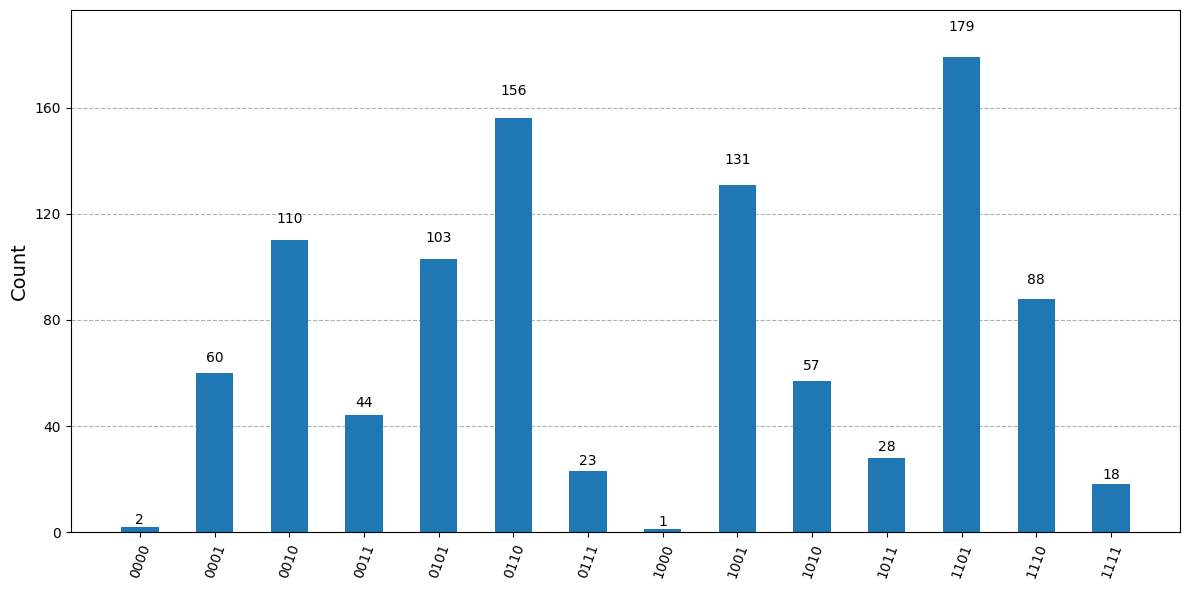

In [19]:
# 6. 결과 히스토그램 시각화
print("\n--- 결과 히스토그램 ---")
fig_hist = plot_histogram(counts, figsize=(12, 6))
display(fig_hist)